1/1 [==============================] - 1s 736ms/step
Predicted: [('n02106662', 'German_shepherd', 0.4781372)]


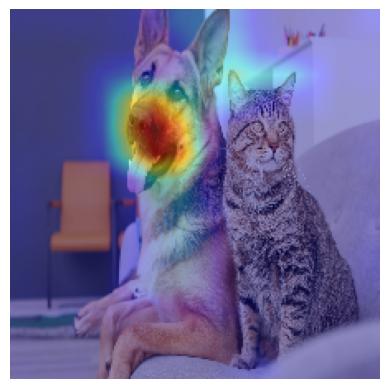

In [28]:
import numpy as np
import cv2
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import tensorflow as tf

# Loading the VGG16 model
model = VGG16(weights='imagenet')

# Loading and preprocesing the image
img_path = '/content/dog_and_cat.jpeg'
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Making predictions
preds = model.predict(x)
predicted_class = np.argmax(preds[0])
print('Predicted:', decode_predictions(preds, top=1)[0])

# Getting the last convolutional layer
last_conv_layer = model.get_layer('block5_conv3')

# Creating a model that maps the input image to the activations of the last conv layer and the output predictions
grad_model = Model(inputs=model.input, outputs=[last_conv_layer.output, model.output])

# Computing the gradient of the top predicted class with regard to the output feature map of the last conv layer
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, predicted_class]

# Extracting the gradients of the loss with respect to the conv layer output
grads = tape.gradient(loss, conv_outputs)

# Pooling the gradients over all the axes
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Converting conv_outputs to a numpy array
conv_outputs = conv_outputs[0].numpy()
pooled_grads = pooled_grads.numpy()

# Multiplying each channel in the feature map array by "how important this channel is" with regard to the top predicted class
for i in range(pooled_grads.shape[-1]):
    conv_outputs[:, :, i] *= pooled_grads[i]

# Generating the heatmap by averaging the weighted feature maps along the channel dimension
heatmap = np.mean(conv_outputs, axis=-1)

# Normalizing the heatmap
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
heatmap = np.uint8(255 * heatmap)

# Superimposing the heatmap on the original image
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)

# Saving and displaying the image
output_path = 'grad_cam_output.jpg'
cv2.imwrite(output_path, superimposed_img)

# Displaying the image
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
